In [33]:
!pip install wordcloud

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [74]:
#Handle Missing Values
df.isnull().sum()
df.dropna(inplace=True)

In [77]:
#Fix Rating Column
df['rate'] = df['rate'].str.replace('/5','')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [79]:
df['approx_cost(for two people)'].head(20)

0                                                   800
1                                                   800
2                                                   800
3                                                   300
4                                                   600
5                                                   600
7                                                   600
9      it turned out worse than the garlic bread. Th...
10                                                  550
11                                                  500
12                                                  600
13                                                  500
14                                                  450
15                                                  800
16                                                  650
17                                                  800
18                                                  700
19                                              

In [81]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

In [83]:
df = df[df['approx_cost(for two people)'].notnull()]

In [85]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

df.dropna(subset=['approx_cost(for two people)'], inplace=True)

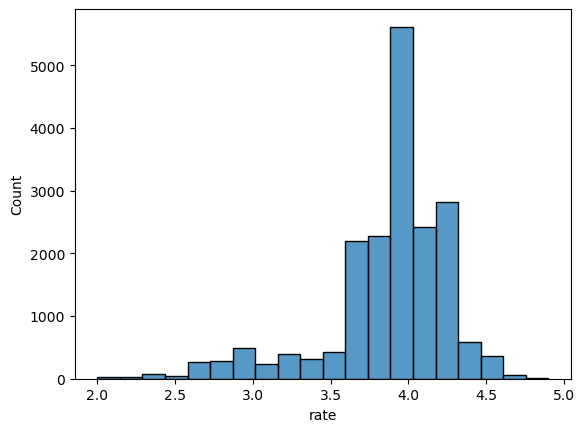

In [87]:
#Exploratory Data Analysis (EDA)
sns.histplot(df['rate'], bins=20)
plt.show()

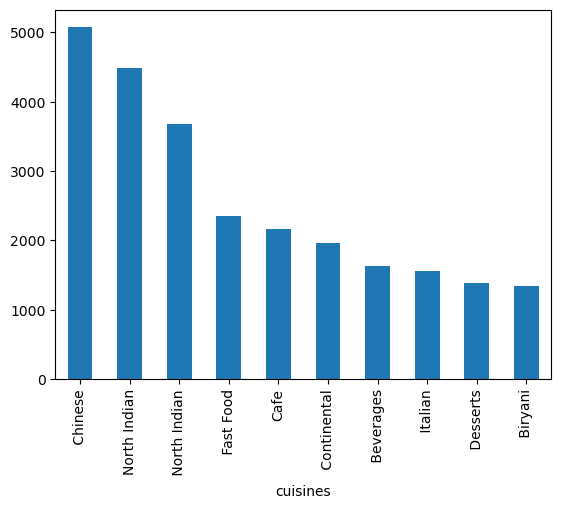

In [89]:
cuisines = df['cuisines'].str.split(',').explode()
cuisines.value_counts().head(10).plot(kind='bar')
plt.show()


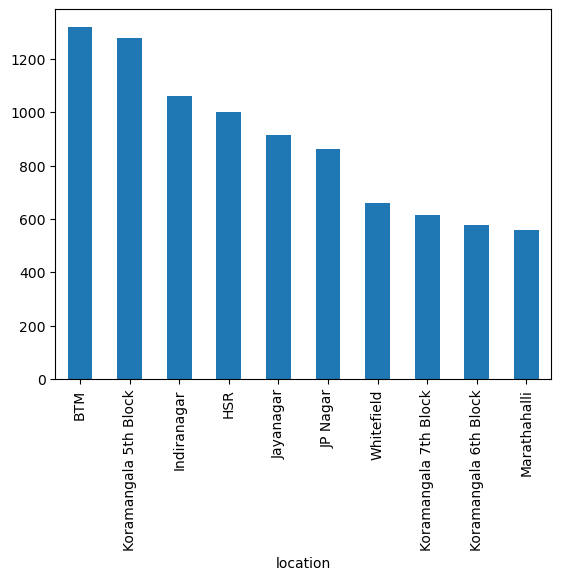

In [91]:
df['location'].value_counts().head(10).plot(kind='bar')
plt.show()

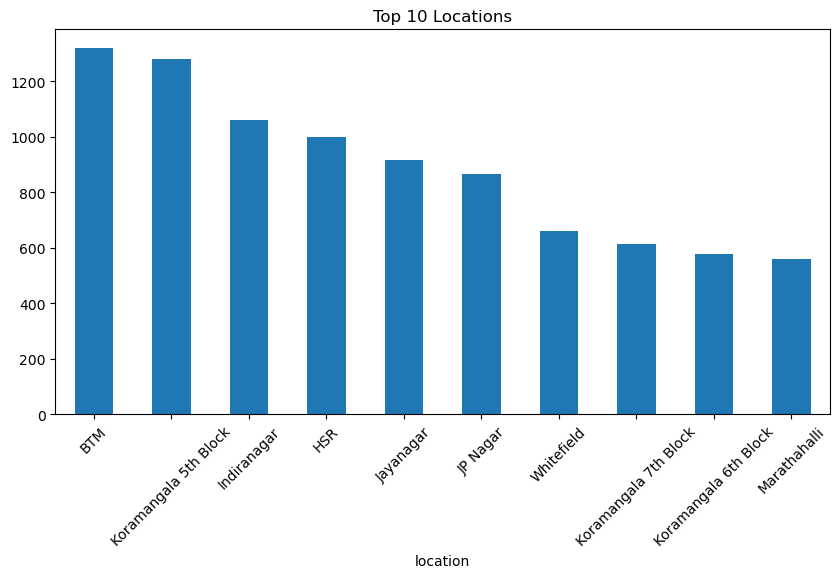

In [93]:
plt.figure(figsize=(10,5))

df['location'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Locations")
plt.xticks(rotation=45)
plt.show()

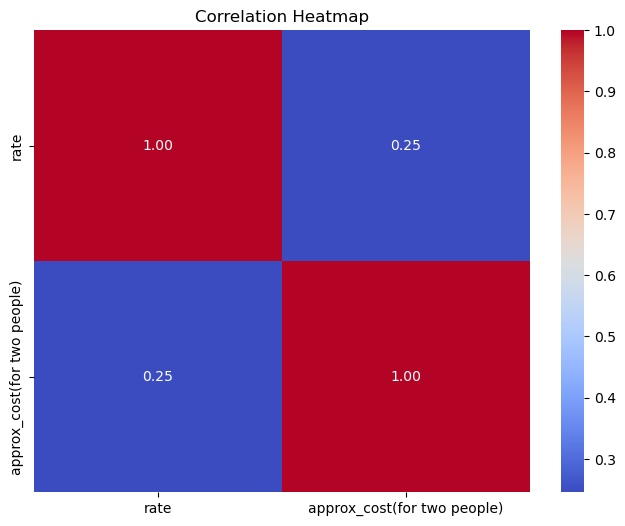

In [95]:
plt.figure(figsize=(8,6))  

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

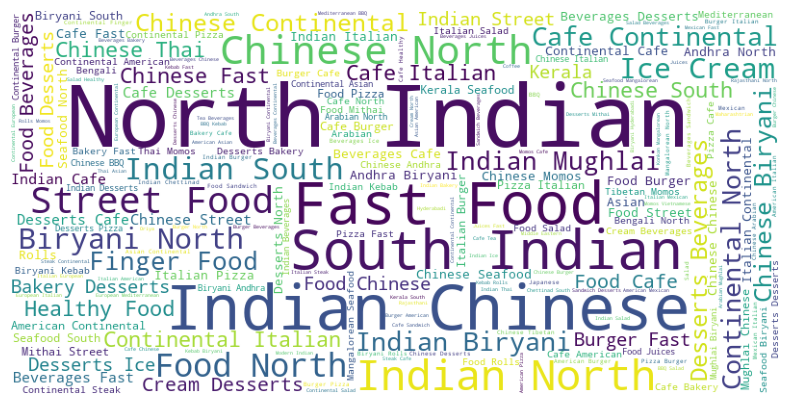

In [97]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cuisines'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()